In [109]:
!pip show chromadb

Name: chromadb
Version: 1.5.9
Summary: Chroma.
Home-page: https://github.com/chroma-core/chroma
Author: 
Author-email: Jeff Huber <jeff@trychroma.com>, Anton Troynikov <anton@trychroma.com>
License: 
Location: C:\Users\Hima Bindu N\anaconda3\Lib\site-packages
Requires: bcrypt, build, grpcio, httpx, importlib-resources, jsonschema, kubernetes, mmh3, numpy, onnxruntime, opentelemetry-api, opentelemetry-exporter-otlp-proto-grpc, opentelemetry-sdk, orjson, overrides, pybase64, pydantic, pydantic-settings, pypika, pyyaml, rich, tenacity, tokenizers, tqdm, typer, typing-extensions, uvicorn
Required-by: 


In [110]:
import chromadb

client = chromadb.PersistentClient(path=r"d:\NLP\dhl_chromadb")
collection = client.get_collection("dhl_intelligence")

# Pull EVERYTHING, not just top-k from a query
all_docs = collection.get()["documents"]
print("Total documents in collection:", len(all_docs))

risk_words = ["tariff", "regulation", "regulatory", "disrupt", "competitor",
              "rival", "shortage", "delay", "layoff", "lawsuit", "fine",
              "penalty", "customs", "strike", "backlash", "criticism"]

for word in risk_words:
    count = sum(1 for d in all_docs if word in d.lower())
    print(f"{word:12s}: {count} documents contain it")

Total documents in collection: 302
tariff      : 17 documents contain it
regulation  : 2 documents contain it
regulatory  : 1 documents contain it
disrupt     : 1 documents contain it
competitor  : 0 documents contain it
rival       : 1 documents contain it
shortage    : 1 documents contain it
delay       : 1 documents contain it
layoff      : 2 documents contain it
lawsuit     : 0 documents contain it
fine        : 0 documents contain it
penalty     : 0 documents contain it
customs     : 6 documents contain it
strike      : 2 documents contain it
backlash    : 0 documents contain it
criticism   : 0 documents contain it


In [111]:
import chromadb
import pandas as pd
import re

client = chromadb.PersistentClient(path=r"d:\NLP\dhl_chromadb")
collection = client.get_collection("dhl_intelligence")

print("Documents:", collection.count())

# Corrected category definitions: occurrence-weighted scoring across ALL
# categories (no if/elif order bias), with risk-tariff and AI added as
# their own categories. "robot" removed as a bare substring — it was
# falsely matching inside "HappyRobot" (an AI agent product name), which
# wrongly inflated automation scores for AI-agent articles.
CATEGORY_KEYWORDS = {
    "automation": {
        "keywords": ["automation", "robotics", "robotic", "autostore", "warehouse"],
        "recommendation": "Accelerate warehouse automation and robotics deployment.",
        "impact": ["Cost Reduction", "Faster Deliveries", "Scalability"],
        "risk": {"financial": "Medium", "operational": "Low", "strategic": "Low"},
    },
    "energy": {
        "keywords": ["battery", "renewable", "energy", "\\bev\\b", "electric", "solar"],
        "recommendation": "Increase investment in New Energy Logistics.",
        "impact": ["Revenue Growth", "Market Differentiation",
                   "Stronger Position in Renewable Energy Supply Chains"],
        "risk": {"financial": "Medium", "operational": "Medium", "strategic": "Low"},
    },
    "sustainability": {
        "keywords": ["sustainability", "sustainable", "carbon", "green logistics", "gogreen"],
        "recommendation": "Expand sustainable logistics initiatives.",
        "impact": ["Environmental Leadership", "Brand Reputation", "Regulatory Compliance"],
        "risk": {"financial": "Low", "operational": "Low", "strategic": "Low"},
    },
    "ecommerce": {
        "keywords": ["fulfillment", "e commerce", "ecommerce", "online retail", "parcel"],
        "recommendation": "Expand e-commerce fulfillment capabilities.",
        "impact": ["Customer Growth", "Revenue Increase", "Scalable Operations"],
        "risk": {"financial": "Low", "operational": "Low", "strategic": "Low"},
    },
    "partnership": {
        "keywords": ["partnership", "partnerships", "agreement", "alliance",
                     "collaboration", "logistikpartnerschaft"],
        "recommendation": "Strengthen strategic partnerships and alliances.",
        "impact": ["Market Expansion", "Shared Innovation", "Competitive Advantage"],
        "risk": {"financial": "Low", "operational": "Low", "strategic": "Low"},
    },
    "ai": {
        "keywords": ["artificial intelligence", "\\bai\\b", "machine learning",
                     "ai agent", "ai-powered", "ai-driven", "predictive analytics"],
        "recommendation": "Invest in AI-powered logistics optimization.",
        "impact": ["Operational Efficiency", "Predictive Analytics", "Competitive Advantage"],
        "risk": {"financial": "Low", "operational": "Low", "strategic": "Low"},
    },
    "supply_chain_risk": {
        "keywords": ["disruption", "disrupt", "delay", "shortage", "bottleneck",
                     "tariff", "customs"],
        "recommendation": "Strengthen supply chain resilience and contingency planning.",
        "impact": ["Business Continuity", "Reduced Disruption", "Operational Stability"],
        "risk": {"financial": "Medium", "operational": "Medium", "strategic": "Medium"},
    },
}

MIN_SCORE_THRESHOLD = 2


def _count_occurrences(keyword, text):
    """Count ALL occurrences (not just presence) so a category with many
    repeated mentions correctly outweighs a category with one incidental hit."""
    if "\\b" in keyword:
        return len(re.findall(keyword, text))
    return text.count(keyword)


def score_categories(docs_text):
    scores = {}
    for category, info in CATEGORY_KEYWORDS.items():
        counts = {kw: _count_occurrences(kw, docs_text) for kw in info["keywords"]}
        matched = {kw.replace("\\b", ""): c for kw, c in counts.items() if c > 0}
        scores[category] = {"score": sum(matched.values()), "matched_keywords": matched}
    return scores


def strategic_analysis(query, n_results=10, verbose_scores=False):

    results = collection.query(
        query_texts=[query],
        n_results=n_results
    )

    docs = results["documents"][0]
    docs_text = " ".join(docs).lower()

    scores = score_categories(docs_text)
    sorted_cats = sorted(scores.items(), key=lambda x: -x[1]["score"])
    best_cat, best_info = sorted_cats[0]

    if best_info["score"] >= MIN_SCORE_THRESHOLD:
        cat_def = CATEGORY_KEYWORDS[best_cat]
        recommendation = cat_def["recommendation"]
        impact = cat_def["impact"]
        risk = cat_def["risk"]
    else:
        recommendation = "Continue monitoring market developments."
        impact = ["Market Awareness"]
        risk = {"financial": "Unknown", "operational": "Unknown", "strategic": "Unknown"}

    print("=" * 60)
    print("STRATEGIC RECOMMENDATION")
    print("=" * 60)

    print("\nQuery:", query)

    print("\nRecommendation:")
    print(recommendation)

    print("\nSupporting Evidence:")
    for i, doc in enumerate(docs[:5], 1):
        print(f"\nEvidence {i}:")
        print(doc[:250])

    print("\nExpected Impact:")
    for item in impact:
        print("-", item)

    print("\nRisk Assessment:")
    print("- Financial Risk:", risk["financial"])
    print("- Operational Risk:", risk["operational"])
    print("- Strategic Risk:", risk["strategic"])

    print("\nPriority:")
    print("HIGH" if best_info["score"] >= 10 else "MEDIUM" if best_info["score"] >= MIN_SCORE_THRESHOLD else "LOW")

    if verbose_scores:
        print("\n[debug] All category scores:")
        for cat, s in sorted_cats:
            print(f"  {cat}: {s['score']} {s['matched_keywords']}")

    return {
        "query": query,
        "category": best_cat if best_info["score"] >= MIN_SCORE_THRESHOLD else "general",
        "recommendation": recommendation,
        "impact": impact,
        "risk": risk,
        "score": best_info["score"],
    }


Documents: 302


In [112]:
#Sustainability...
strategic_analysis(
    "DHL sustainability strategy"
)

STRATEGIC RECOMMENDATION

Query: DHL sustainability strategy

Recommendation:
Expand sustainable logistics initiatives.

Supporting Evidence:

Evidence 1:
shaping sustainable future dhl remarkable shift towards dhl global leader logistics express mail services recognized imperative took upon catalyze change 2 dhls journey towards sustainability

Evidence 2:
sustainability dhl fulfillment network united states dhl fulfillment network goes beyond sustainable partner sustainability integrated every level guides

Evidence 3:
dhl sustainability status dhl dhl sustainability status environmentally friendly shipment delivery

Evidence 4:
sustainability approach dhl group strategy 2030 accelerate green logistics choice fourth bottom line complementing targets dhl group sustainability journey destination

Evidence 5:
sustainable product portfolio dhl germany dhl global forwarding offering guidance increase carbon efficiency reduce co e emissions optimized supply chain design together dhl sustai

{'query': 'DHL sustainability strategy',
 'category': 'sustainability',
 'recommendation': 'Expand sustainable logistics initiatives.',
 'impact': ['Environmental Leadership',
  'Brand Reputation',
  'Regulatory Compliance'],
 'risk': {'financial': 'Low', 'operational': 'Low', 'strategic': 'Low'},
 'score': 26}

In [113]:
#E-Commerce
strategic_analysis(
    "DHL e commerce fulfillment growth"
)

STRATEGIC RECOMMENDATION

Query: DHL e commerce fulfillment growth

Recommendation:
Expand e-commerce fulfillment capabilities.

Supporting Evidence:

Evidence 1:
dhl supply chain setzt mit seinem europ ischen fulfillment netzwerk neuen branchenstandard im e commerce postbranche de postbranche de february 2 2021 hier bietet dhl supply chain f hrender anbieter der kontraktlogistik und teil von deutsche post dhl

Evidence 2:
dhl ecommerce usps enter 10 billion plus long term exclusive agreement dhl ecommerce reaffirms exclusivity relationship usps last mile delivery united states expanding collaboration allows dhl ecommerce strengthen u market position fully leveraging s

Evidence 3:
may 06 2025 dhl supply chain strengthens offering marks second e commerce acquisition dhl supply chain 2025 acquired inmar reverse logistics business january making

Evidence 4:
dhl supply chain erweitert die logistikpartnerschaft mit iglo august 18 2022 dhl supply chain der auf kontraktlogistik spezialisier

{'query': 'DHL e commerce fulfillment growth',
 'category': 'ecommerce',
 'recommendation': 'Expand e-commerce fulfillment capabilities.',
 'impact': ['Customer Growth', 'Revenue Increase', 'Scalable Operations'],
 'risk': {'financial': 'Low', 'operational': 'Low', 'strategic': 'Low'},
 'score': 14}

In [114]:
#Partnerships
strategic_analysis(
    "DHL strategic partnerships"
)

STRATEGIC RECOMMENDATION

Query: DHL strategic partnerships

Recommendation:
Expand e-commerce fulfillment capabilities.

Supporting Evidence:

Evidence 1:
dhl ecommerce usps enter 10 billion plus long term exclusive agreement dhl ecommerce reaffirms exclusivity relationship usps last mile delivery united states expanding collaboration allows dhl ecommerce strengthen u market position fully leveraging s

Evidence 2:
sustainability dhl fulfillment network united states dhl fulfillment network goes beyond sustainable partner sustainability integrated every level guides

Evidence 3:
dhl supply chain erweitert die logistikpartnerschaft mit iglo august 18 2022 dhl supply chain der auf kontraktlogistik spezialisierte gesch ftsbereich der deutsche post dhl group wird mit beginn des kommenden

Evidence 4:
dhl supply chain dhl supply chain world leading logistics provider combining strength dhl group capabilities proven adaptability uniquely positioned

Evidence 5:
dhl home global logistics int

{'query': 'DHL strategic partnerships',
 'category': 'ecommerce',
 'recommendation': 'Expand e-commerce fulfillment capabilities.',
 'impact': ['Customer Growth', 'Revenue Increase', 'Scalable Operations'],
 'risk': {'financial': 'Low', 'operational': 'Low', 'strategic': 'Low'},
 'score': 8}

In [115]:
#AI & Analytics
strategic_analysis(
    "DHL AI analytics machine learning"
)

STRATEGIC RECOMMENDATION

Query: DHL AI analytics machine learning

Recommendation:
Invest in AI-powered logistics optimization.

Supporting Evidence:

Evidence 1:
nov 11 2025 dhl boosts operational efficiency customer communications happyrobot ai agents dhl group november 11 2025 part structured strategic approach ai dhl supply chain systematically identifying validating operational use cases generative agenti

Evidence 2:
dhl integrates happyrobot ai agents streamline logistics dhl supply chain partnering happyrobot roll autonomous ai agents handle high volume communication streamline scheduling improve warehouse coordination enhance customer service initiative part d

Evidence 3:
dhl ai agent bet logistics ops leaders debales ai ready see ai agents handle appointment scheduling check calls email automation way dhl without 18 month build timeline

Evidence 4:
dhl automates warehouse operations power real time data processing analytics efficient inventory management predictive mainten

{'query': 'DHL AI analytics machine learning',
 'category': 'ai',
 'recommendation': 'Invest in AI-powered logistics optimization.',
 'impact': ['Operational Efficiency',
  'Predictive Analytics',
  'Competitive Advantage'],
 'risk': {'financial': 'Low', 'operational': 'Low', 'strategic': 'Low'},
 'score': 22}

In [116]:
#Warehouse Automation....
strategic_analysis(
    "DHL warehouse automation opportunities"
)

STRATEGIC RECOMMENDATION

Query: DHL warehouse automation opportunities

Recommendation:
Accelerate warehouse automation and robotics deployment.

Supporting Evidence:

Evidence 1:
dhl scales global operations warehouse automation april 7 2025 decade dhl supply chain modernizing warehouse operations autostore systems seeking enable swift scalability standardized automation across global markets working autostore world leading l

Evidence 2:
dhl automates warehouse operations power real time data processing analytics efficient inventory management predictive maintenance dhl able automate

Evidence 3:
dhl leans automation new chicago e commerce facility automation key investment area dhl dhl invests 300m expand automate us e commerce network max garland sept

Evidence 4:
dhl autostore expand global warehouse automation apr 29 2026 dhl supply chain autostore enhancing global warehouse automation 1 000 robots learn partnership expansion dhl supply chain currently involved nine autostore pr

{'query': 'DHL warehouse automation opportunities',
 'category': 'automation',
 'recommendation': 'Accelerate warehouse automation and robotics deployment.',
 'impact': ['Cost Reduction', 'Faster Deliveries', 'Scalability'],
 'risk': {'financial': 'Medium', 'operational': 'Low', 'strategic': 'Low'},
 'score': 30}

In [117]:
#Renewable Energy...
strategic_analysis(
    "DHL renewable energy logistics opportunities"
)

STRATEGIC RECOMMENDATION

Query: DHL renewable energy logistics opportunities

Recommendation:
Increase investment in New Energy Logistics.

Supporting Evidence:

Evidence 1:
dhl logistics things insights world logistics battery energy storage systems dhl new energy logistics bridging gap renewable electricity generation demand

Evidence 2:
dhl targets 3bn new energy logistics revenue 2030 1 week ago dhl group expanding presence new energy sector aiming increase revenue related logistics activities approximately 600 million 2025 3 billion 2030 governments industries invest energy resili

Evidence 3:
dhl targets growing new energy logistics market air cargo news dhl investing services targeting new energy logistics market looks double revenues generated sector target sector company add new time definite service also continuing invest electric veh

Evidence 4:
sustainability approach dhl group strategy 2030 accelerate green logistics choice fourth bottom line complementing targets dhl gr

{'query': 'DHL renewable energy logistics opportunities',
 'category': 'energy',
 'recommendation': 'Increase investment in New Energy Logistics.',
 'impact': ['Revenue Growth',
  'Market Differentiation',
  'Stronger Position in Renewable Energy Supply Chains'],
 'risk': {'financial': 'Medium', 'operational': 'Medium', 'strategic': 'Low'},
 'score': 17}

In [118]:
queries = [
    "DHL warehouse automation opportunities",
    "DHL renewable energy logistics opportunities",
    "DHL sustainability strategy",
    "DHL e commerce fulfillment growth",
    "DHL strategic partnerships",
    "DHL AI analytics machine learning"
]

# NOTE: previously called strategic_analysis_report(), a second, even more
# minimal broken if/elif copy of the same logic in cell above. Removed as
# redundant dead code — this now reuses the single corrected
# strategic_analysis() function defined above, so there is only ONE
# scoring implementation in this notebook instead of two diverging copies.
report = []

for q in queries:
    result = strategic_analysis(q)
    report.append({
        "Query": result["query"],
        "Category": result["category"],
        "Recommendation": result["recommendation"],
        "Score": result["score"],
    })

report_df = pd.DataFrame(report)

report_df

STRATEGIC RECOMMENDATION

Query: DHL warehouse automation opportunities

Recommendation:
Accelerate warehouse automation and robotics deployment.

Supporting Evidence:

Evidence 1:
dhl scales global operations warehouse automation april 7 2025 decade dhl supply chain modernizing warehouse operations autostore systems seeking enable swift scalability standardized automation across global markets working autostore world leading l

Evidence 2:
dhl automates warehouse operations power real time data processing analytics efficient inventory management predictive maintenance dhl able automate

Evidence 3:
dhl leans automation new chicago e commerce facility automation key investment area dhl dhl invests 300m expand automate us e commerce network max garland sept

Evidence 4:
dhl autostore expand global warehouse automation apr 29 2026 dhl supply chain autostore enhancing global warehouse automation 1 000 robots learn partnership expansion dhl supply chain currently involved nine autostore pr

,Query,Category,Recommendation,Score
0,DHL warehouse automation opportunities,automation,Accelerate warehouse automation and robotics d...,30
1,DHL renewable energy logistics opportunities,energy,Increase investment in New Energy Logistics.,17
2,DHL sustainability strategy,sustainability,Expand sustainable logistics initiatives.,26
3,DHL e commerce fulfillment growth,ecommerce,Expand e-commerce fulfillment capabilities.,14
4,DHL strategic partnerships,ecommerce,Expand e-commerce fulfillment capabilities.,8
5,DHL AI analytics machine learning,ai,Invest in AI-powered logistics optimization.,22


In [119]:
report_df.to_csv(
    "strategic_recommendations.csv",
    index=False
)

print("Report saved.")

Report saved.


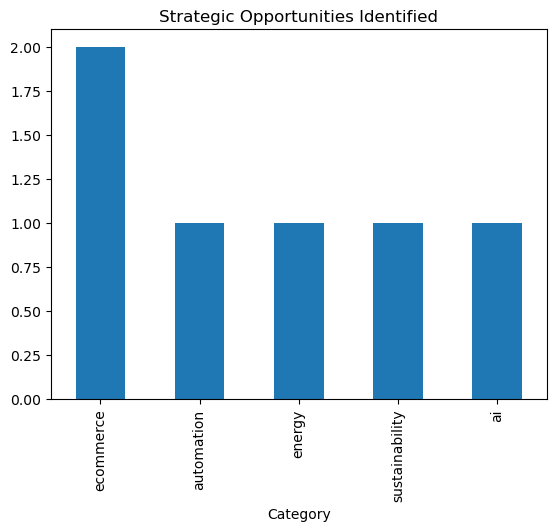

In [120]:
import matplotlib.pyplot as plt

report_df["Category"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Strategic Opportunities Identified"
)

plt.show()